In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u




In [3]:
hdul = fits.open('himanga_merged_integration_table.fits')
hdul.info()
table_data = hdul[1].data
hdul.close()

print(table_data.names)
#print(table_data['OBJECT'])
#print(table_data['OBJECT'].dtype)
#print(table_data.columns)


Filename: himanga_merged_integration_table.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  SINGLE DISH    1 BinTableHDU  11330   963294R x 76C   [32A, D, 22A, D, D, D, 16A, 6A, 8A, D, D, D, 4A, D, 4A, D, I, 32A, 32A, J, 32A, 16A, E, 8A, D, D, D, D, D, D, D, D, D, D, D, D, 8A, D, D, 12A, I, I, D, D, I, 1A, I, I, 16A, 16A, J, J, 22A, D, D, I, 1A, D, E, D, 1A, 1A, 8A, E, E, 16A, I, I, I, K, L, 10A, D, D, D, D]   


    Header size is not multiple of 2880: 1
There may be extra bytes after the last HDU or the file is corrupted. [astropy.io.fits.hdu.hdulist]


['OBJECT', 'BANDWID', 'DATE-OBS', 'DURATION', 'EXPOSURE', 'TSYS', 'TDIM7', 'TUNIT7', 'CTYPE1', 'CRVAL1', 'CRPIX1', 'CDELT1', 'CTYPE2', 'CRVAL2', 'CTYPE3', 'CRVAL3', 'CRVAL4', 'OBSERVER', 'OBSID', 'SCAN', 'OBSMODE', 'FRONTEND', 'TCAL', 'VELDEF', 'VFRAME', 'RVSYS', 'OBSFREQ', 'LST', 'AZIMUTH', 'ELEVATIO', 'TAMBIENT', 'PRESSURE', 'HUMIDITY', 'RESTFREQ', 'FREQRES', 'EQUINOX', 'RADESYS', 'TRGTLONG', 'TRGTLAT', 'SAMPLER', 'FEED', 'SRFEED', 'FEEDXOFF', 'FEEDEOFF', 'SUBREF_STATE', 'SIDEBAND', 'PROCSEQN', 'PROCSIZE', 'PROCSCAN', 'PROCTYPE', 'LASTON', 'LASTOFF', 'TIMESTAMP', 'QD_XEL', 'QD_EL', 'QD_BAD', 'QD_METHOD', 'VELOCITY', 'ZEROCHAN', 'DOPFREQ', 'SIG', 'CAL', 'CALTYPE', 'TWARM', 'TCOLD', 'CALPOSITION', 'IFNUM', 'PLNUM', 'FDNUM', 'INTNUM', 'FLAG', 'FLAGID', 'ADCSAMPF', 'VSPDELT', 'VSPRVAL', 'VSPRPIX']


In [4]:
import numpy as np


# Extract unique flags and their counts
unique_flagid, counts2 = np.unique(table_data['FLAGID'], return_counts=True)

# Zip them into a dictionary for easy searching
counts_dict = dict(zip(unique_flagid, counts2))


# Safely get the counts (the '0' prevents an error if the flag is missing)
gps_count = counts_dict.get('GPS', 0)
auto_gps_count = counts_dict.get('autoGPS', 0)

print(f"GPs count: {gps_count}")
print(f"autoGPs count: {auto_gps_count}")


unique_flags, counts = np.unique(table_data['FLAG'], return_counts=True)

print("\nFlag Types and Counts:")
for flag, count in zip(unique_flags, counts):
    print(f"Flag value '{flag}': {count} observations")

good_data_mask = table_data['FLAG'] == 0

# This new table ONLY contains the reliable, unflagged observations
clean_table = table_data[good_data_mask]

print(f"\nKept {len(clean_table)} good observations out of {len(table_data)}.")

GPs count: 9163
autoGPs count: 21400

Flag Types and Counts:
Flag value 'False': 932730 observations
Flag value 'True': 30564 observations

Kept 932730 good observations out of 963294.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table


# Wrapping original data in an Astropy Table makes it modifiable
new_table = Table(table_data)

# Calculate redshift for ALL objects (flagged and unflagged)
all_redshifts = (new_table['RESTFREQ'] - new_table['OBSFREQ']) / new_table['OBSFREQ']

# Because it is an Astropy Table, we can now add the column without a KeyError!
new_table['REDSHIFT'] = all_redshifts

print(f"Success! 'new_table' now has {len(new_table)} rows and a 'REDSHIFT' column.")



# We still want to filter out the bad data before plotting
good_data_mask = new_table['FLAG'] == "FALSE"
clean_table = new_table[good_data_mask]
print(new_table)


Success! 'new_table' now has 963294 rows and a 'REDSHIFT' column.
   OBJECT    BANDWID          DATE-OBS        ... VSPRPIX       REDSHIFT      
----------- ---------- ---------------------- ... ------- --------------------
  8141-3702 23437500.0 2016-02-02T21:26:56.00 ...     nan 0.023917660885705513
  8141-3702 23437500.0 2016-02-02T21:26:56.00 ...     nan  0.02207571901092729
  8141-3702 23437500.0 2016-02-02T21:27:06.00 ...     nan 0.023917660885705513
  8141-3702 23437500.0 2016-02-02T21:27:06.00 ...     nan  0.02207571901092729
  8141-3702 23437500.0 2016-02-02T21:27:16.00 ...     nan 0.023917660885705513
  8141-3702 23437500.0 2016-02-02T21:27:16.00 ...     nan  0.02207571901092729
  8141-3702 23437500.0 2016-02-02T21:27:26.00 ...     nan 0.023917660885705513
  8141-3702 23437500.0 2016-02-02T21:27:26.00 ...     nan  0.02207571901092729
  8141-3702 23437500.0 2016-02-02T21:27:35.99 ...     nan 0.023917660885705513
  8141-3702 23437500.0 2016-02-02T21:27:35.99 ...     nan  0.0220

In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# --- Extracting everything directly from table_data ---

# 1. Extract RESTFREQ for GPS
gps_data = table_data[table_data['FLAGID'] == 'GPS']['OBSFREQ']

# 2. Extract RESTFREQ for autoGPS
auto_gps_data = table_data[table_data['FLAGID'] == 'autoGPS']['OBSFREQ']

# 3. Extract RESTFREQ for the "Good Observations" (where FLAG is 0)
good_obs_data = table_data[table_data['FLAGID'] != "autoGPS"]['OBSFREQ']

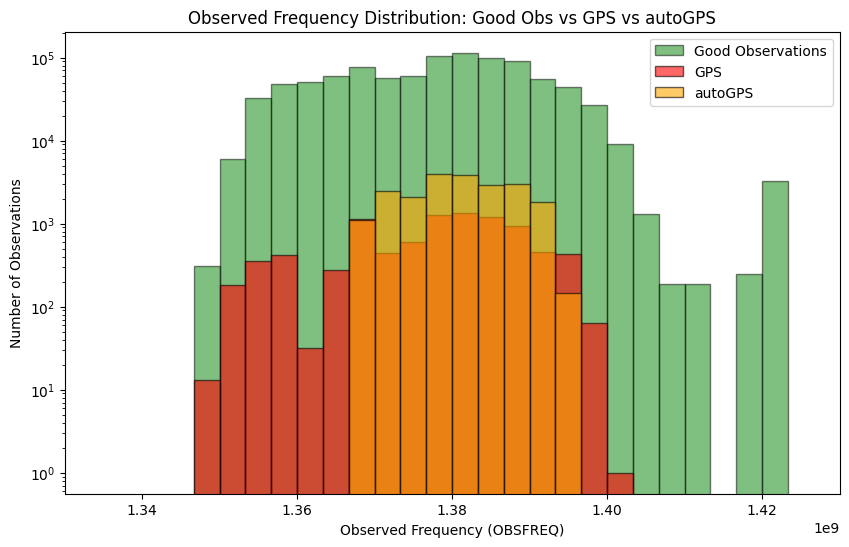

Number of Good Obs: 941894
Number of GPS Obs: 9163
Number of autoGPS Obs: 21400


In [7]:

# Set up the plot size
plt.figure(figsize=(10, 6))

# Plot all three histograms on the same figure
# The 'alpha' parameter makes the colors transparent so you can see overlaps
plt.hist(good_obs_data, range = (1330e6, 1430e6), bins=30, alpha=0.5, label='Good Observations', color='green', edgecolor='black')
plt.hist(gps_data, range = (1330e6, 1430e6), bins=30, alpha=0.6, label='GPS', color='red', edgecolor='black')
plt.hist(auto_gps_data, range = (1330e6, 1430e6), bins=30, alpha=0.6, label='autoGPS', color='orange', edgecolor='black')

# Add labels and a legend
plt.xlabel('Observed Frequency (OBSFREQ)')
plt.ylabel('Number of Observations')
plt.title('Observed Frequency Distribution: Good Obs vs GPS vs autoGPS')
plt.yscale('log')
plt.xlim(1330e6, 1430e6)

# Display the legend so you know which color is which
plt.legend(loc='upper right')

# Show the plot
plt.show()


print(f"Number of Good Obs: {len(good_obs_data)}")
print(f"Number of GPS Obs: {len(gps_data)}")
print(f"Number of autoGPS Obs: {len(auto_gps_data)}")

In [8]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# --- Extracting everything directly from table_data ---

# 1. Extract RESTFREQ for GPS
gps_datav = table_data[table_data['FLAGID'] == 'GPS']['VELOCITY']

# 2. Extract RESTFREQ for autoGPS
auto_gps_datav = table_data[table_data['FLAGID'] == 'autoGPS']['VELOCITY']

# 3. Extract RESTFREQ for the "Good Observations" (where FLAG is 0)
good_obs_datav = table_data[table_data['FLAGID'] != "autoGPS"]['VELOCITY']

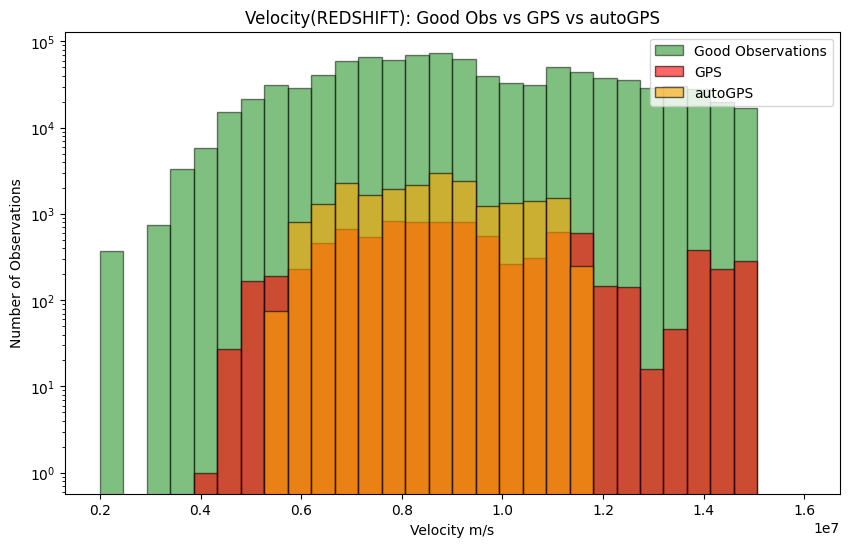

Number of Good Obs: 941894
Number of GPS Obs: 9163
Number of autoGPS Obs: 21400


In [9]:
# Set up the plot size
plt.figure(figsize=(10, 6))

# Plot all three histograms on the same figure
# The 'alpha' parameter makes the colors transparent so you can see overlaps
plt.hist(good_obs_datav, range=(0.2e7, 1.6e7), bins=30, alpha=0.5, label='Good Observations', color='green', edgecolor='black')
plt.hist(gps_datav, range=(0.2e7, 1.6e7), bins=30, alpha=0.6, label='GPS', color='red', edgecolor='black')
plt.hist(auto_gps_datav, range=(0.2e7, 1.6e7), bins=30, alpha=0.6, label='autoGPS', color='orange', edgecolor='black')

# Add labels and a legend
plt.xlabel('Velocity m/s')
plt.ylabel('Number of Observations')
plt.title('Velocity(REDSHIFT): Good Obs vs GPS vs autoGPS')
plt.yscale('log')
#plt.xlim(1330e6, 1430e6)

# Display the legend so you know which color is which
plt.legend(loc='upper right')

# Show the plot
plt.show()


print(f"Number of Good Obs: {len(good_obs_data)}")
print(f"Number of GPS Obs: {len(gps_data)}")
print(f"Number of autoGPS Obs: {len(auto_gps_data)}")

In [10]:
#import os

# 1. Define where you want the file to go and what it should be named
#save_directory = '/Users/angelhuitzil/Downloads/AstroSummer2026'
#file_path_csv = os.path.join(save_directory, 'hi_manga_with_redshifts.csv')

# 2. Make sure the folder actually exists (creates it if it doesn't)
#os.makedirs(save_directory, exist_ok=True)

# 3. Write the table to a CSV file
#new_table.write(file_path_csv, format='csv', overwrite=True)

#print(f"Table successfully saved to: {file_path_csv}")


In [11]:
gps_dates = table_data[table_data['FLAGID'] == 'GPS']['DATE-OBS']
auto_gps_dates = table_data[table_data['FLAGID'] == 'autoGPS']['DATE-OBS']

print(auto_gps_dates)
print(gps_dates)

['2016-02-09T00:07:27.00' '2016-02-09T00:07:37.00'
 '2016-02-09T00:07:47.00' ... '2025-11-20T00:17:27.50'
 '2025-11-20T00:17:37.50' '2025-11-20T00:17:47.50']
['2016-02-08T23:18:40.00' '2016-02-08T23:24:26.00'
 '2016-02-08T23:24:36.00' ... '2025-11-19T21:57:56.50'
 '2025-11-19T23:22:13.50' '2025-11-20T00:16:37.50']


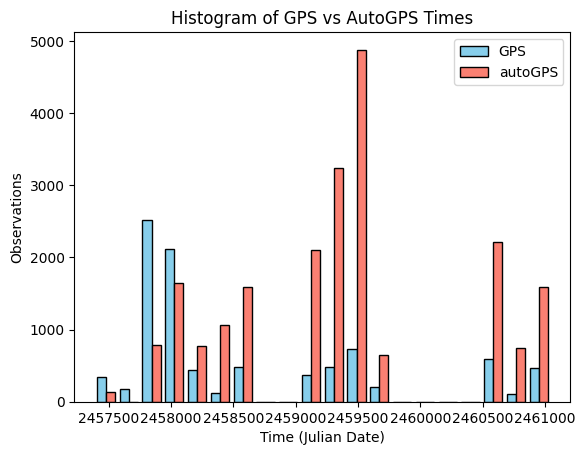

In [14]:
from astropy.time import Time
import matplotlib.pyplot as plt


gps_dates = table_data[table_data['FLAGID'] == 'GPS']['DATE-OBS']
auto_gps_dates = table_data[table_data['FLAGID'] == 'autoGPS']['DATE-OBS']


gps_jd = Time(gps_dates).jd
auto_gps_jd = Time(auto_gps_dates).jd

plt.hist([gps_jd, auto_gps_jd], range=(2457388,2461041), bins=20, label=['GPS', 'autoGPS'], color=['skyblue', 'salmon'], edgecolor='black')


plt.xlabel('Time (Julian Date)')
plt.ticklabel_format(style='plain', axis='x')
plt.ylabel('Observations')
plt.title('Histogram of GPS vs AutoGPS Times')
plt.legend()
plt.show()
